## Importing libraries

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading dataset

In [99]:
df = pd.read_csv('Telco-Customer-Churn.csv')

## Data understanding

In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [101]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [102]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

Obzirom da je 'TotalCharges' pohranjen kao string podatak, izvršena je konverzija u numerički tip podatka

### Za svaku kolonu je prikaza broj jedinstvenih vrijednosti te relativna frekvencija

In [103]:
for col in df.columns:
    print(f"--- Kolona: {col} ---")
    print(f"Broj jedinstvenih: {df[col].nunique()}")
    print("Relativna frekvencija (procenti):")
    print(df[col].value_counts(normalize=True) * 100)
    print("\n")

--- Kolona: customerID ---
Broj jedinstvenih: 7043
Relativna frekvencija (procenti):
customerID
7590-VHVEG    0.014198
5575-GNVDE    0.014198
3668-QPYBK    0.014198
7795-CFOCW    0.014198
9237-HQITU    0.014198
                ...   
6840-RESVB    0.014198
2234-XADUH    0.014198
4801-JZAZL    0.014198
8361-LTMKD    0.014198
3186-AJIEK    0.014198
Name: proportion, Length: 7043, dtype: float64


--- Kolona: gender ---
Broj jedinstvenih: 2
Relativna frekvencija (procenti):
gender
Male      50.47565
Female    49.52435
Name: proportion, dtype: float64


--- Kolona: SeniorCitizen ---
Broj jedinstvenih: 2
Relativna frekvencija (procenti):
SeniorCitizen
0    83.785319
1    16.214681
Name: proportion, dtype: float64


--- Kolona: Partner ---
Broj jedinstvenih: 2
Relativna frekvencija (procenti):
Partner
No     51.69672
Yes    48.30328
Name: proportion, dtype: float64


--- Kolona: Dependents ---
Broj jedinstvenih: 2
Relativna frekvencija (procenti):
Dependents
No     70.041176
Yes    29.958824

Iz ove analize uočavam skoro jednaku raspodjelu spolova. Dalje, zanimljivo je izdvojiti informaciju da preko 50% korisnika koristi tip ugovora od mjeseca do mjeseca, dok je najmanje korisnika koji potpisuju ugovor na godinu dana. 

Kada je u pitanju način plaćanja, sve metode plaćanja su ravnomjerno raspoređene, bez većih odstupanja. 

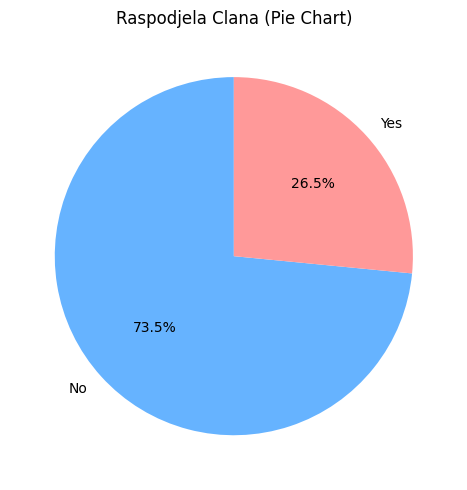

In [104]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
plt.title('Raspodjela Clana (Pie Chart)')

plt.tight_layout()
plt.show()

C:\Users\system64\AppData\Local\Temp\ipykernel_13120\3768581415.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_charges, x='Contract', y='MonthlyCharges', palette='magma')


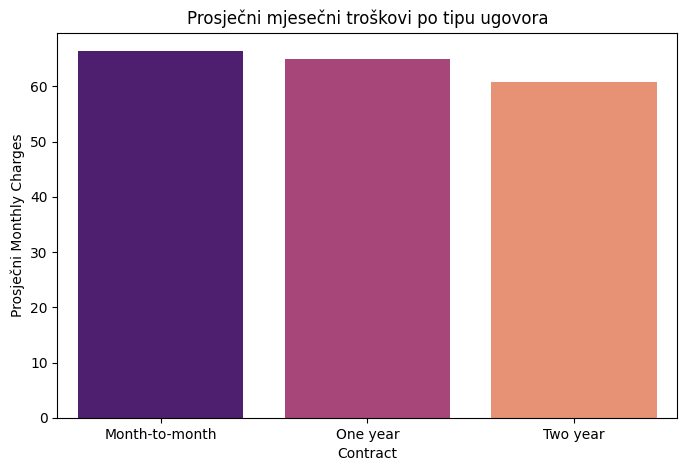

Tabelarni prikaz:
         Contract  MonthlyCharges
0  Month-to-month       66.398490
1        One year       65.048608
2        Two year       60.770413


In [105]:
contract_charges = df.groupby('Contract')['MonthlyCharges'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=contract_charges, x='Contract', y='MonthlyCharges', palette='magma')
plt.title('Prosječni mjesečni troškovi po tipu ugovora')
plt.ylabel('Prosječni Monthly Charges')
plt.show()

print("Tabelarni prikaz:")
print(contract_charges)

Najveći prosječni trošak imaju korisnici koji plaćaju "iz mjeseca u mjesec" (66.40), dok je najniži kod onih sa ugovorom na dvije godine (60.77).

C:\Users\system64\AppData\Local\Temp\ipykernel_13120\1155791213.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


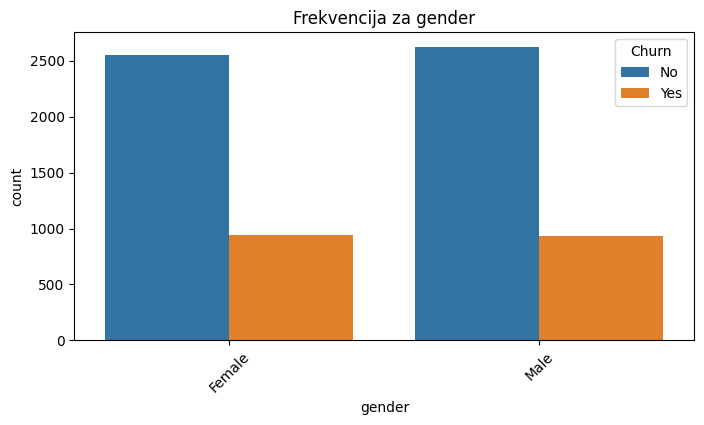

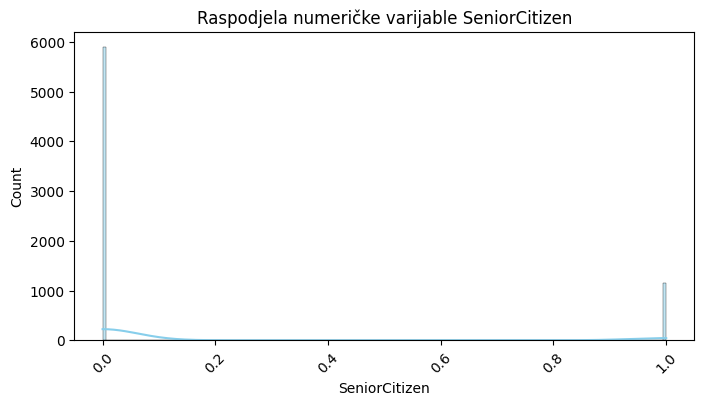

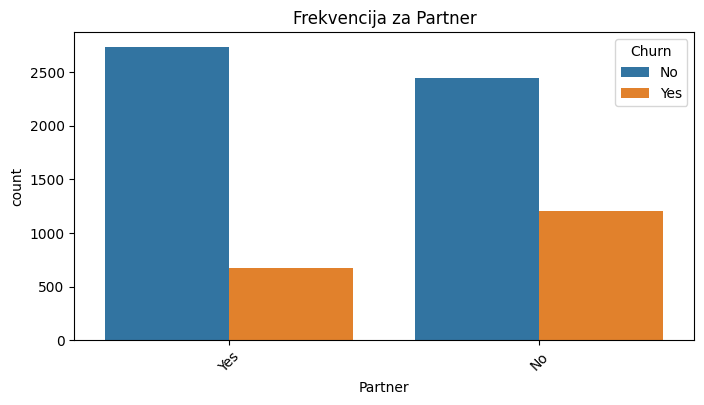

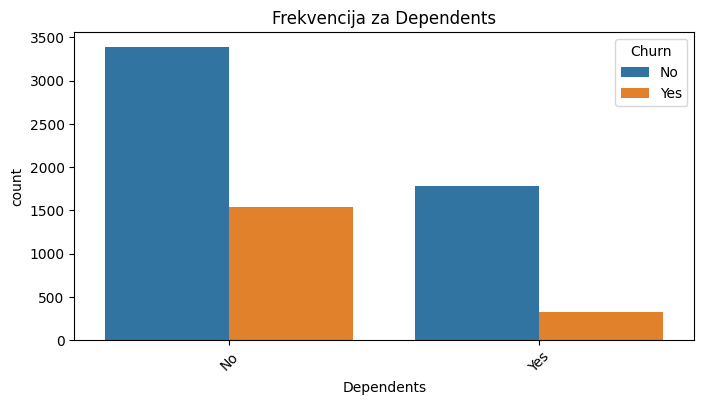

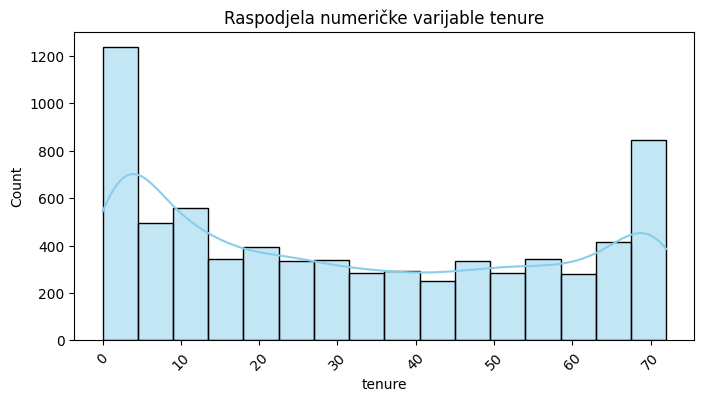

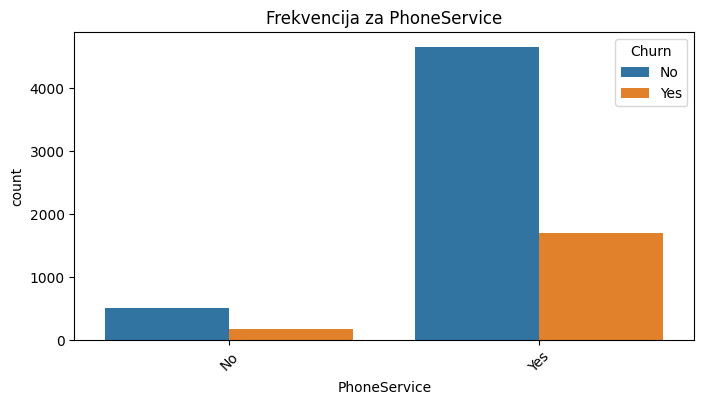

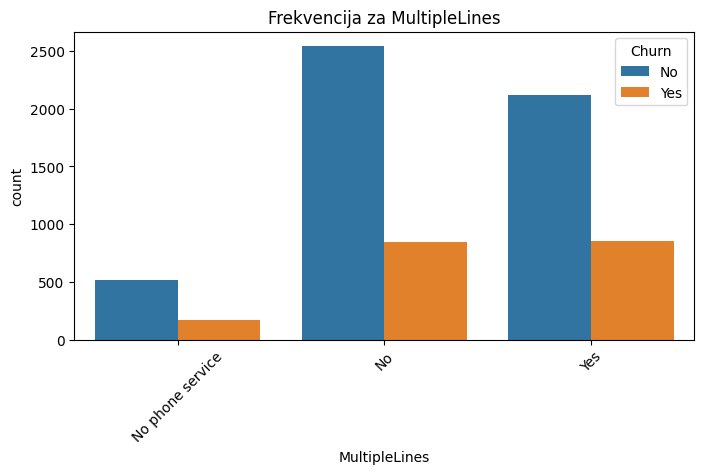

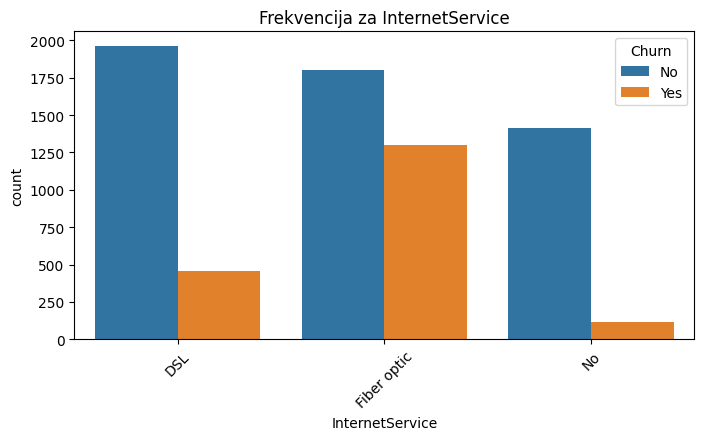

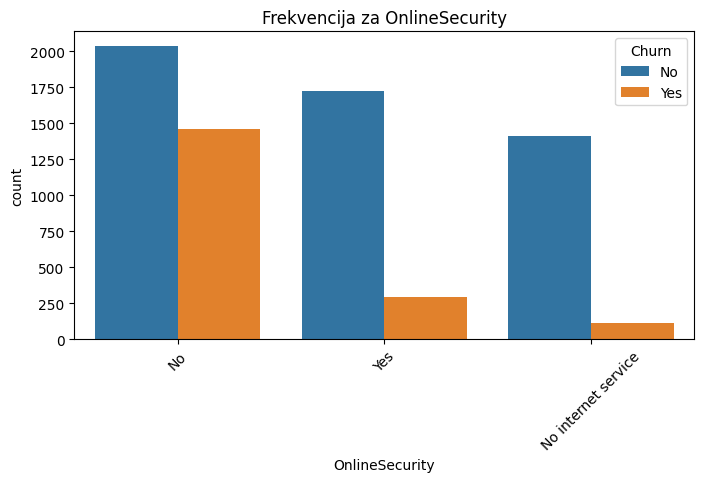

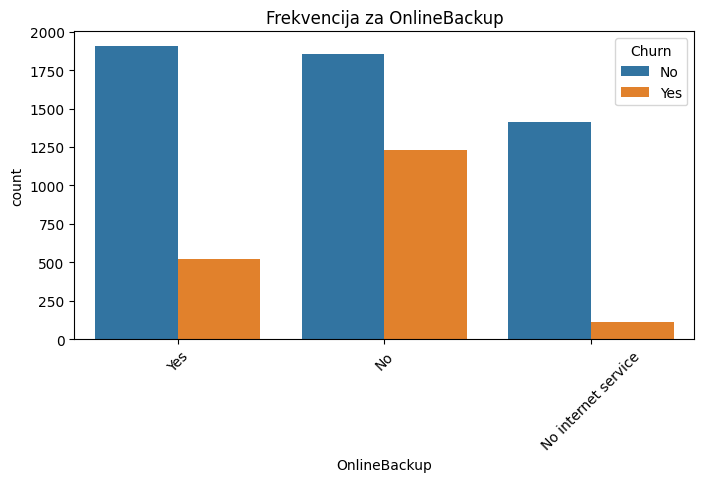

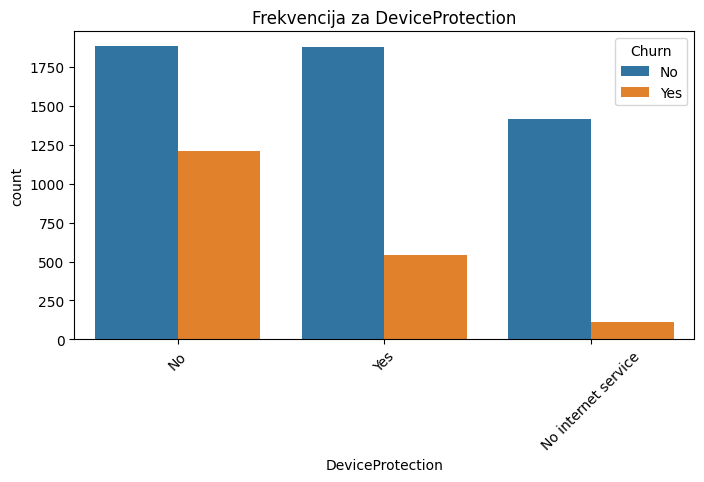

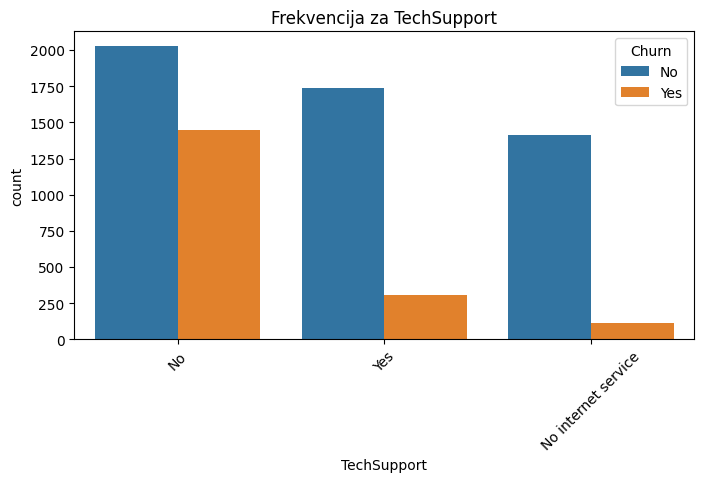

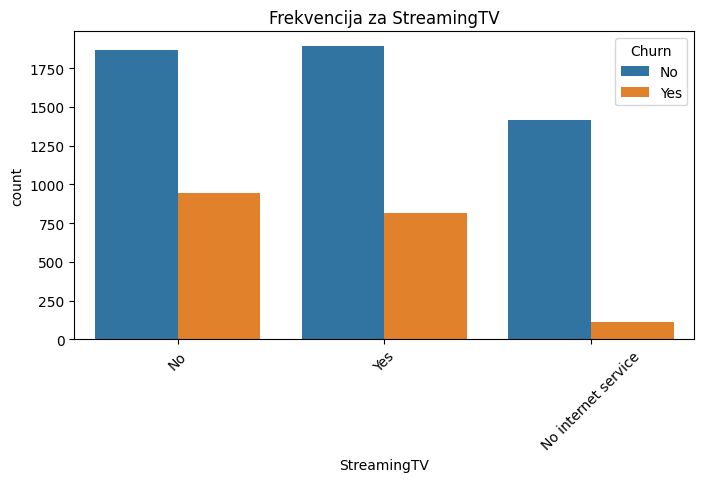

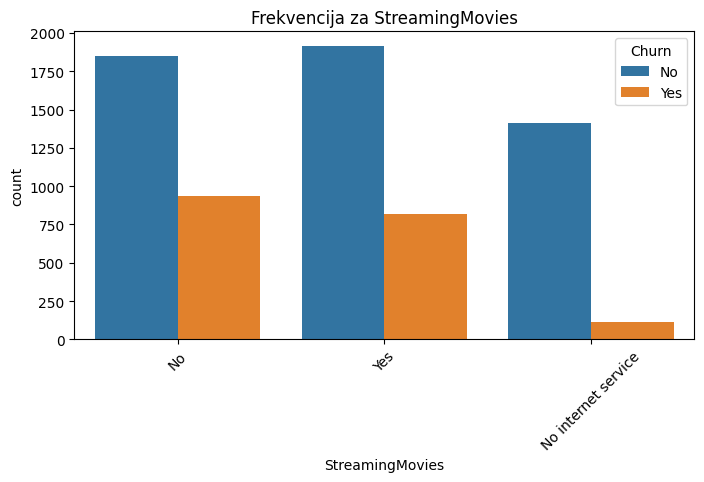

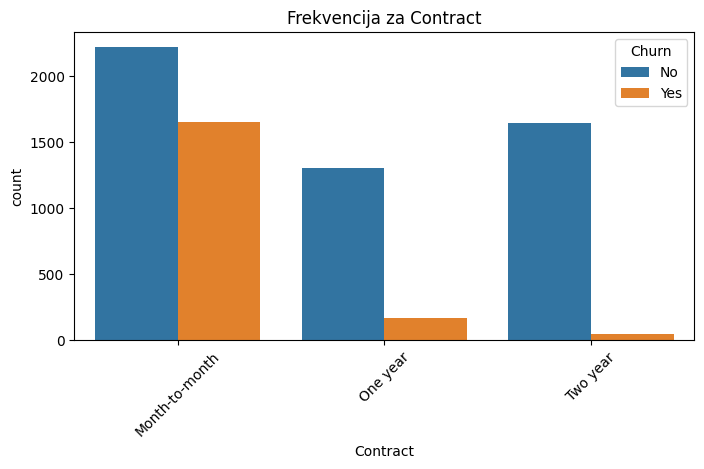

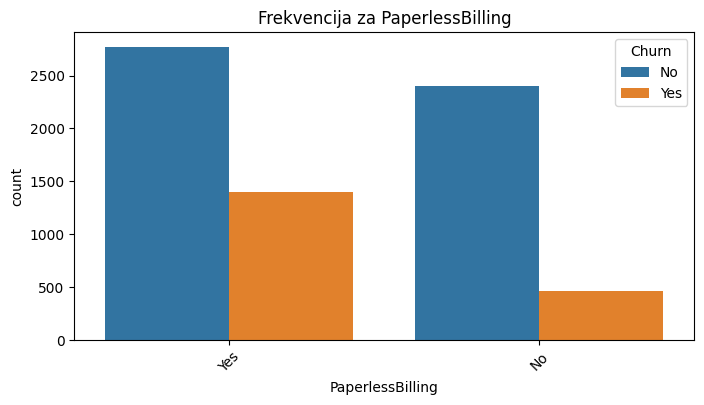

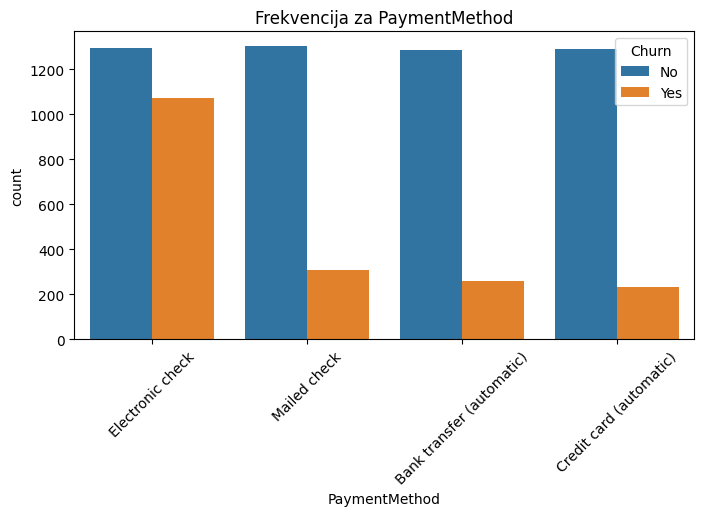

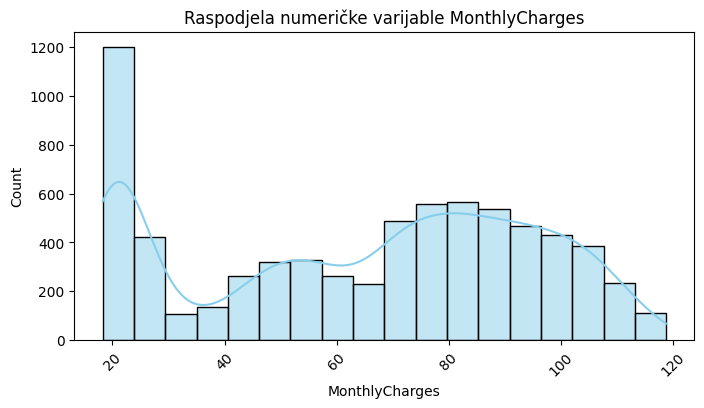

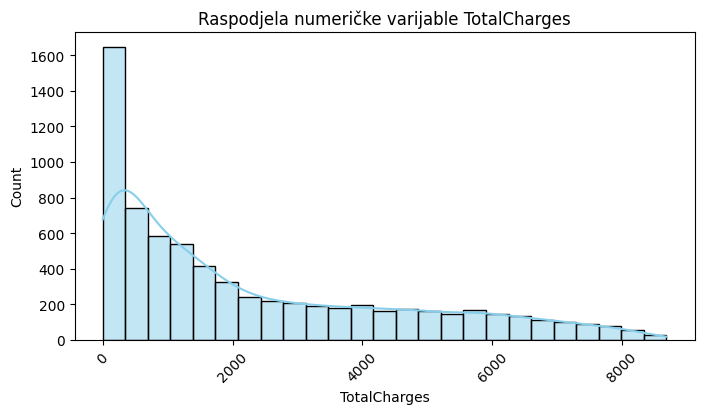

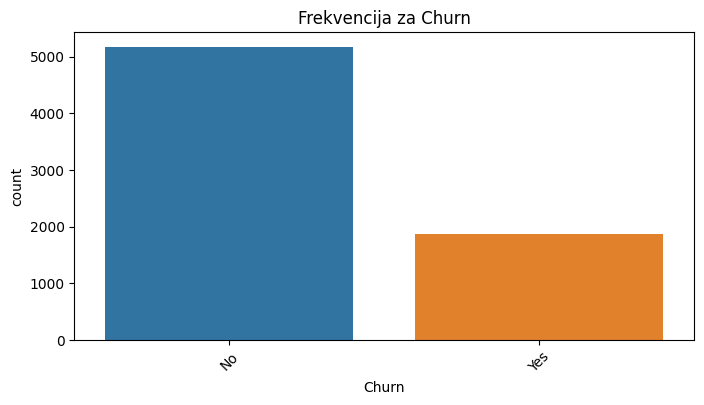

In [106]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in df.columns:
    if col == 'customerID':
        continue 
        
    plt.figure(figsize=(8, 4))
    if col in categorical_cols:
        sns.countplot(data=df, x=col, hue='Churn')
        plt.title(f'Frekvencija za {col}')
    else:
        sns.histplot(df[col], kde=True, color='skyblue')
        plt.title(f'Raspodjela numeričke varijable {col}')
    
    plt.xticks(rotation=45)
    plt.show()

## Data preprocessing

## Data cleaning

In [107]:
df.drop(columns=['customerID'], inplace=True)

Kolona customerID je uklonjena zbog toga što ne doprinosti cjelokupnoj analizi.

In [108]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

Obzirom da u mom datasetu ima dosta kolona koje nisu numeričke, odlučila sam pomoću for petlje proći kroz sve kategoričke kolone i odrediti njihove jedinstvene vrijednosti.

In [109]:
categorical_cols = df.select_dtypes(include=['object', 'str']).columns

print("--- JEDINSTVENE VRIJEDNOSTI PO KOLONAMA ---")
for col in categorical_cols:
    unique_vals = df[col].unique()
    print(f"Kolona '{col}' ({len(unique_vals)} vrijednosti):")
    print(unique_vals)
    print("-" * 30)

--- JEDINSTVENE VRIJEDNOSTI PO KOLONAMA ---
Kolona 'gender' (2 vrijednosti):
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
------------------------------
Kolona 'Partner' (2 vrijednosti):
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
------------------------------
Kolona 'Dependents' (2 vrijednosti):
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
------------------------------
Kolona 'PhoneService' (2 vrijednosti):
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
------------------------------
Kolona 'MultipleLines' (3 vrijednosti):
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
------------------------------
Kolona 'InternetService' (3 vrijednosti):
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
------------------------------
Kolona 'OnlineSecurity' (3 vrijednosti):
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
------------------------------
Kolona 'OnlineBackup' (3 vrijednosti):
<StringArray>
['Yes',

In [110]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

if 'gender' in df.columns:
    df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})


In [111]:
df['MultipleLines'].unique()

<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

In [112]:
df['MultipleLines'] = df[col].map({
    'No': 0, 
    'Yes': 1, 
    'No phone service': 2
})

In [113]:
df['InternetService'].unique()

<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

In [114]:
df['InternetService'] = df[col].map({
    'DSL': 0, 
    'Fiber optic': 1, 
    'No': 2
})

In [115]:
df['OnlineSecurity'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [116]:
df['OnlineSecurity'] = df[col].map({
    'DSL': 0, 
    'Fiber optic': 1, 
    'No': 2
})

In [117]:
df['OnlineBackup'].unique()

<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

In [118]:
df['OnlineBackup'] = df[col].map({
    'Yes': 0, 
    'No': 1, 
    'No internet service': 2
})

In [119]:
df['DeviceProtection'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [120]:
df['DeviceProtection'] = df[col].map({
    'No': 0, 
    'Yes': 1, 
    'No internet service': 2
})

In [121]:
df['TechSupport'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [122]:
df['TechSupport'] = df[col].map({
    'No': 0, 
    'Yes': 1, 
    'No internet service': 2
})

In [124]:
df['StreamingTV'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [125]:
df['StreamingTV'] = df[col].map({
    'No': 0, 
    'Yes': 1, 
    'No internet service': 2
})

In [126]:
df['StreamingMovies'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [127]:
df['StreamingMovies'] = df[col].map({
    'No': 0, 
    'Yes': 1, 
    'No internet service': 2
})

In [128]:
df['Contract'].unique()

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [129]:
df['Contract'] = df[col].map({
    'Month-to-month': 0, 
    'One year': 1, 
    'Two year': 2
})

In [130]:
df['PaymentMethod'].unique()

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [131]:
df['PaymentMethod'] = df[col].map({
    'Electronic check': 0, 
    'Mailed check': 1, 
    'Bank transfer (automatic)': 2,
    'Credit card (automatic)': 3
})

In [132]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     0 non-null      float64
 7   InternetService   0 non-null      float64
 8   OnlineSecurity    0 non-null      float64
 9   OnlineBackup      0 non-null      float64
 10  DeviceProtection  0 non-null      float64
 11  TechSupport       0 non-null      float64
 12  StreamingTV       0 non-null      float64
 13  StreamingMovies   0 non-null      float64
 14  Contract          0 non-null      float64
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     0 non-null      float64
 17  Monthl

## Data preparation for models training